## Debug the dataloader

[TRANSFORM] Train: normalize=True
[DEBUG 2026-04-02 12:26:44.200] ToTensor input size=(64, 64), mode=L
[DEBUG 2026-04-02 12:26:44.201] ToTensor output shape=(1, 64, 64), min=0.106, max=0.961
image shape  : torch.Size([1, 64, 64])
image range  : -1.6555356979370117 to 2.0776607990264893
landmarks    : torch.Size([6, 2])
landmark range: 0.22299064695835114 to 0.772429883480072
mask         : tensor([1., 1., 1., 1., 1., 1.])
visibility   : tensor([1.])
image path   : /inwdata2a/sudhanshu/Unet_training_script/data-and-labels/phase-2-face-crops-for-labelling/0c423e27-d170-4ce9-a64a-d2b156867bf2/frame_0469_face00.jpg


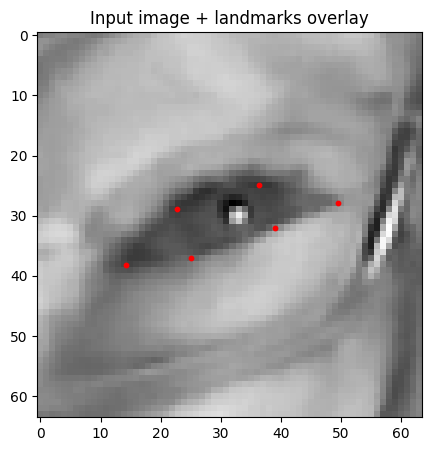

In [1]:
import sys
sys.path.insert(0, "/inwdata2a/sudhanshu/Unet_training_script")

from src.dataset import EyeDataset
from src.transforms import build_train_transforms
from src.utils import load_config
import matplotlib.pyplot as plt

cfg = load_config("/inwdata2a/sudhanshu/Unet_training_script/configs/default.yaml")

# load just ONE sample — no training loop needed
dataset = EyeDataset(cfg['paths']['test_csv'], cfg, transform=build_train_transforms(cfg), is_train=True)
sample  = dataset[1000]

img      = sample['image']        # tensor
landmarks = sample['landmarks']   # tensor
mask     = sample['mask']         # tensor
vis      = sample['visibility']   # tensor
path     = sample['img_path']       # string

# ── sanity checks ─────────────────────────────────────────────────────────────
print("image shape  :", img.shape)           # expect [1, 64, 64]
print("image range  :", img.min().item(), "to", img.max().item())  # expect ~[-1, 1] or [0, 1]
print("landmarks    :", landmarks.shape)     # expect [num_landmarks, 2]
print("landmark range:", landmarks.min().item(), "to", landmarks.max().item())  # expect [0, 1] normalized?
print("mask         :", mask)                # which landmarks are valid
print("visibility   :", vis)                 # blink/visibility flags
print("image path   :", path)                # sanity check for correct image loading

# ── visualize image + landmarks overlay ───────────────────────────────────────
plt.figure(figsize=(5, 5))
plt.imshow(img.squeeze(), cmap='gray')
# scale landmarks to pixel space for plotting
h, w = img.shape[1], img.shape[2]
lmk_px = landmarks.numpy() * [w, h]         # if landmarks are normalized 0-1
plt.scatter(lmk_px[:, 0], lmk_px[:, 1], c='red', s=10)
plt.title("Input image + landmarks overlay")
plt.show()

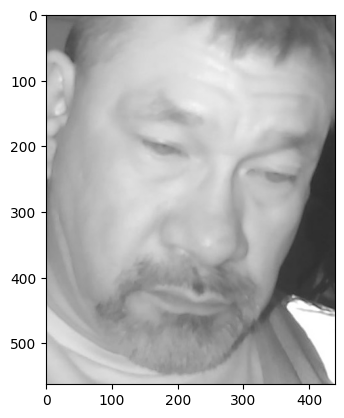

In [50]:
from PIL import Image
import matplotlib.pyplot as plt
img_path = "/inwdata2a/sudhanshu/Unet_training_script/data-and-labels/phase-1-face-crops-for-labelling/28e3d6f4-4842-4d2b-81d0-606b21f22118/frame_1262_face_0.jpg"
img = Image.open(img_path)
plt.imshow(img, cmap='gray')
plt.show()

## Check the Dyotana model and freeze it before using it as backbone 

In [51]:
# ── STANDALONE DEBUG CELL ─────────────────────────────────────────────────────
# Goal: test model loading + forward pass WITHOUT touching the training pipeline
# Run this in a notebook or as a plain python script independently

import sys
import torch

# ── Step 1: point to your source directories manually ─────────────────────────
sys.path.insert(0, "/inwdata2a/sudhanshu/Unet_training_script")

# ── Step 2: import ONLY what you need — not the whole pipeline ─────────────────
from src.utils import load_frozen_unet_segmentation_model


import types

# ── Step 3: load the model ─────────────────────────────────────────────────────
frozen_backbone_model = load_frozen_unet_segmentation_model(
    "/inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt",
    device="cpu"
)

# ── Step 4: create a random input matching what the model expects ──────────────
# UnetUpSample_modified expects: [batch, channels, height, width]
# From config we know: single channel input, 64x64 image
dummy_input = torch.randn(1, 1, 64, 64)   # batch=1, channel=1, H=64, W=64

# ── Step 5: forward pass ───────────────────────────────────────────────────────
with torch.no_grad():
    output1, output2 = frozen_backbone_model(dummy_input)

# ── Step 6: verify output shapes make sense ────────────────────────────────────
print("output1 shape:", output1.shape)   # expected: [1, 64, 64]   — segmentation map
print("output2 shape:", output2.shape)   # expected: [1, 1, 64, 64] — blink probability
print("output1 unique values:", output1.unique())          # should be 0-3 (argmax of 4 classes)
print("output2 range:", output2.min().item(), "to", output2.max().item())  # should be 0-1 (sigmoid)
print("\n✅ Model loads and runs correctly")




### The general debugging framework — 4 questions to always ask
'''
1. WHAT do I want to test?
   → just the model? just a loss function? just a dataloader?

2. WHAT does it need to run?
   → trace only the direct dependencies, ignore everything else

3. WHAT goes in?
   → figure out the input shape/type and create a fake one with torch.randn / torch.zeros

4. WHAT should come out?
   → know the expected output shape and value range before you run it
      so you can immediately tell if something is wrong'''



---unet segmentor with upsample layers---
NUM PARAMS = 66761

[INFO] Loaded and froze UnetUpSample_modified from: /inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt
[INFO] Total frozen params: 66761
output1 shape: torch.Size([1, 64, 64])
output2 shape: torch.Size([1, 1, 64, 64])
output1 unique values: tensor([0])
output2 range: 1.1115797865501875e-10 to 0.0005736308521591127

✅ Model loads and runs correctly


'\n1. WHAT do I want to test?\n   → just the model? just a loss function? just a dataloader?\n\n2. WHAT does it need to run?\n   → trace only the direct dependencies, ignore everything else\n\n3. WHAT goes in?\n   → figure out the input shape/type and create a fake one with torch.randn / torch.zeros\n\n4. WHAT should come out?\n   → know the expected output shape and value range before you run it\n      so you can immediately tell if something is wrong'

## Load the full model using the frozen backbone dyotana model

In [63]:
from models.unet_encoder_model import EyeLandmarkWithFrozenSegmentationBackbone

model=EyeLandmarkWithFrozenSegmentationBackbone(
    segmentation_model=frozen_backbone_model
)

dummy_input = torch.randn(1, 1, 64, 64)   # batch=1, channel=1, H=64, W=64
output = model(dummy_input)

for outputs in output:
    print(outputs)

print("heatmap shape:", output["heatmaps"].shape)   # expected: [1, num_landmarks, 64, 64]
print("coords shape:", output["coords"].shape)   


[INFO] Frozen segmentation model (all params set to requires_grad=False)
[INFO] Created EyeLandmarkWithFrozenSegmentationBackbone:
  - Frozen segmentation model params: 66761
  - Trainable heatmap head params: 14086
heatmaps
coords
output1
output2
heatmap shape: torch.Size([1, 6, 64, 64])
coords shape: torch.Size([1, 6, 2])


## Debug NaN in eye_visibility

In [8]:
import pandas as pd

df= pd.read_csv("/inwdata2a/sudhanshu/Unet_training_script/data-and-labels/final_split/train.csv")
print(df['eye_visibility'].isna().sum())
print(df['eye_visibility'].unique())


nan_rows= df[df['eye_visibility'].isna()]
print(nan_rows)

0
[ True False]
Empty DataFrame
Columns: [video_id, frame_key, eye_side, eye_visibility, path_to_dataset, eye_bbox_face, landmarks_coordinates_inside_eye_bbox]
Index: []
